# EDA: indicador da criança alfabetizada no Brasil

## Objetivo
O modelo futuro pretende prever se um aluno será classificado como alfabetizado ou não. Entretanto, os dados disponíveis não contêm observações por aluno: a maior parte do conjunto está agregada em nível municipal, UF ou escola.

Por isso, esta EDA é feita com duas finalidades complementares:
1. analisar o máximo possível dos dados disponíveis para identificar quais fatores estão associados ao desempenho de alfabetização;
2. definir a melhor estratégia de modelagem e o melhor proxy de label que permita aproximar a predição do nível individual, mesmo com a limitação de agregação.


Dessa forma, a análise não ignora a realidade estrutural dos dados: ela reconhece que a previsão por aluno exige um proxy contextual e que o melhor uso dos dados disponíveis deve priorizar a qualidade do aprendizado e a robustez do modelo.

As perguntas centrais da EDA são:
1. Quais variáveis têm relação mais forte com a alfabetização?
2. Quais bases ajudam mais a explicar o desempenho e quais são apenas contexto, redundância ou risco de vazamento?
3. Como construir um alvo supervisionado razoável quando os dados reais não estão no nível do aluno?

## 1. Inventário das bases e papel de cada uma

Foram identificadas nove bases na pasta `dados`:

- `wide_analitica_alfabetizacao.csv` → principal base de análise; nível município; contém o indicador de alfabetização e as variáveis de proficiência e contexto territorial
- `indicador_alfabetizacao_municipio.csv` → base equivalente em nível município, útil para validar e comparar a mesma métrica em outra forma estrutural
- `resultado_metas_municipio.csv` → resultado em relação às metas de alfabetização; é útil para contextualizar o desempenho, mas não é a fonte principal do alvo
- `comparacao_metas_resultados.csv` → comparação entre meta e resultado; útil para avaliação do desempenho, mas não deve ser usada como feature principal de predição
- `evolucao_temporal_indicador.csv` → série temporal do indicador; útil para entender a dinâmica, mas potencialmente contaminada por dependência temporal do próprio alvo
- `dados_cadunico_2023_a_2026.csv` → dados socioeconômicos e de renda por município/mês; importante para explicar diferenças de contexto social
- `censo_escolar_2023_2024.csv` → base de infraestrutura escolar em nível escola; relevante para contextualização, mas muito agregada para a previsão direta no nível do aluno
- `indicadores_educacionais_uf_2021_2026.csv` → indicadores de UF; útil para contexto macro e comparação regional
- `indicadores_educacionais_brasil_2021_2026.csv` → indicadores nacionais; úteis para contexto macro, mas não para modelagem local

### Critério de seleção para a previsão futura
Para um modelo supervisionado, a base ideal precisa ter quatro características:
- granularidade compatível com a unidade de análise pretendida;
- variável alvo bem definida;
- preditores disponíveis na mesma escala de observação;
- ausência de vazamento de informação do próprio alvo.

No caso real do problema, a unidade alvo ideal seria o aluno. Como não existe essa base, a melhor estratégia é usar um proxy de alfabetização em nível município/ano e, em seguida, modelar o risco de alfabetização a partir do contexto escolar e socioeconômico. Isso não prediz o aluno individualmente de forma literal, mas reduz a lacuna de informação e produz um modelo melhor do que usar apenas uma das bases em isolamento.

### Decisão analítica
As bases de maior valor para o modelo são, em ordem de prioridade:
1. `wide_analitica_alfabetizacao.csv` — principal base do indicador e da variável-alvo proxy
2. `dados_cadunico_2023_a_2026.csv` — contexto socioeconômico
3. `censo_escolar_2023_2024.csv` — contexto institucional/infraestrutural, após agregação

As demais bases foram exploradas como contexto, mas não representam a melhor fonte primária para a previsão final, por serem derivadas do indicador, agregadas demais ou pouco alinhadas com a unidade de observação desejada.

In [9]:
import pandas as pd
from pathlib import Path
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns

base_path = Path.cwd().parent / 'data'

# Carregamento das bases-chave
wide = pd.read_csv(base_path / 'wide_analitica_alfabetizacao.csv')
municipio = pd.read_csv(base_path / 'indicador_alfabetizacao_municipio.csv')
res_meta = pd.read_csv(base_path / 'resultado_metas_municipio.csv')
comp_meta = pd.read_csv(base_path / 'comparacao_metas_resultados.csv')
evol = pd.read_csv(base_path / 'evolucao_temporal_indicador.csv')
cad = pd.read_csv(base_path / 'dados_cadunico_2023_a_2026.csv')
uf = pd.read_csv(base_path / 'indicadores_educacionais_uf_2021_2026.csv')
brasil = pd.read_csv(base_path / 'indicadores_educacionais_brasil_2021_2026.csv')

print('wide:', wide.shape)
print('municipio:', municipio.shape)
print('res_meta:', res_meta.shape)
print('comp_meta:', comp_meta.shape)
print('evol:', evol.shape)
print('cad:', cad.shape)
print('uf:', uf.shape)
print('brasil:', brasil.shape)

for name, df in [('wide', wide), ('municipio', municipio), ('res_meta', res_meta), ('comp_meta', comp_meta), ('evol', evol)]:
    print(f'\n--- {name} ---')
    print(df.head(2).to_string(index=False))

wide: (12417, 28)
municipio: (12417, 17)
res_meta: (23995, 29)
comp_meta: (24143, 12)
evol: (24143, 11)
cad: (239521, 10)
uf: (1880, 215)
brasil: (90, 214)

--- wide ---
 id_municipio  nu_rede  nu_serie  id_indicador_municipio      nome_uf nome_regiao   ds_rede  qt_alunos_avaliados  qt_alunos_alfabetizados  qt_alunos_alfabetizados_corte  pc_indicador_alfabetizacao  pc_indicador_alfabetizacao_corte  vl_proficiencia_media  vl_proficiencia_mediana         ts_insercao  pc_taxa_alfabetizacao  pc_participacao_meta  pc_meta_2024  pc_meta_2025  pc_meta_2026  pc_meta_2027  pc_meta_2028  pc_meta_2029  pc_meta_2030  pc_meta_ano_corrente  vl_gap_meta_resultado  nu_ano sigla_uf
      3101805        3         2    -1877581126399192126 Minas Gerais     Sudeste Municipal                   49                       24                             24                       48.98                             48.98                 737.60                   734.01 2026-08-20 01:27:09                  46.13     

## 2. Exploração da base principal: indicadores municipais de alfabetização

A base `wide_analitica_alfabetizacao.csv` é a candidata mais forte porque reúne:
- target direto (`pc_indicador_alfabetizacao`)
- contexto educacional (`vl_proficiencia_media`, `vl_proficiencia_mediana`)
- volume amostral (`qt_alunos_avaliados`)
- contexto territorial (`nome_regiao`, `sigla_uf`, `ds_rede`, `nu_serie`)

Além disso, ela está em nível município/ano, que é o nível mais natural para prever desempenho do aluno em termos agregados de alfabetização.

In [10]:
wide[['pc_indicador_alfabetizacao', 'vl_proficiencia_media', 'vl_proficiencia_mediana', 'qt_alunos_avaliados', 'pc_meta_2024']].describe().round(2)

,pc_indicador_alfabetizacao,vl_proficiencia_media,vl_proficiencia_mediana,qt_alunos_avaliados,pc_meta_2024
count,12417.00,12417.00,12417.00,12417.00,10030.00
mean,62.09,751.84,754.90,270.17,60.93
std,19.83,23.14,24.09,1099.30,17.36
min,0.00,626.29,619.76,1.00,0.00
25%,47.87,736.85,740.53,42.00,50.76
50%,63.21,751.40,755.55,91.00,63.79
75%,77.20,764.84,768.05,214.00,76.01
max,100.00,868.22,874.97,52622.00,80.00


In [11]:
%matplotlib inline

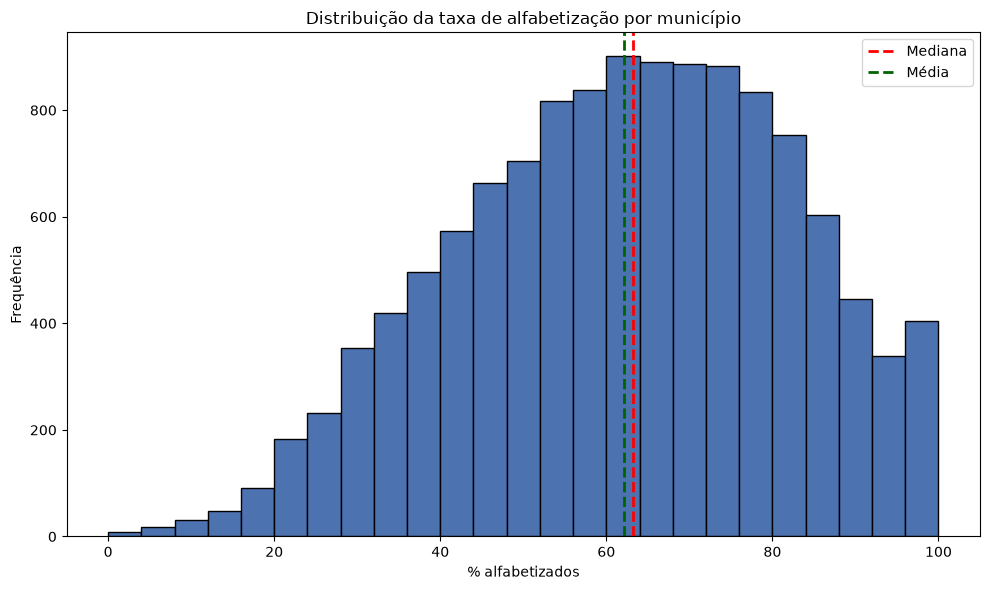

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(wide['pc_indicador_alfabetizacao'].dropna(), bins=25, color='#4C72B0', edgecolor='black')
ax.axvline(wide['pc_indicador_alfabetizacao'].median(), color='red', linestyle='--', linewidth=2, label='Mediana')
ax.axvline(wide['pc_indicador_alfabetizacao'].mean(), color='darkgreen', linestyle='--', linewidth=2, label='Média')
ax.set_title('Distribuição da taxa de alfabetização por município')
ax.set_xlabel('% alfabetizados')
ax.set_ylabel('Frequência')
ax.legend()
plt.tight_layout()
plt.show()

### Interpretação
A distribuição da taxa de alfabetização tem variabilidade importante e é assimétrica. Isso sugere que o problema não é homogêneo e que grupos de municípios apresentam desempenho muito diferente, reforçando a necessidade de incluir fatores contextuais no modelo.

Além disso, a variabilidade no percentual de alfabetizados justifica a seleção de variáveis educacionais e socioeconômicas como preditoras, pois o alvo não é determinado apenas por um único eixo contextual.

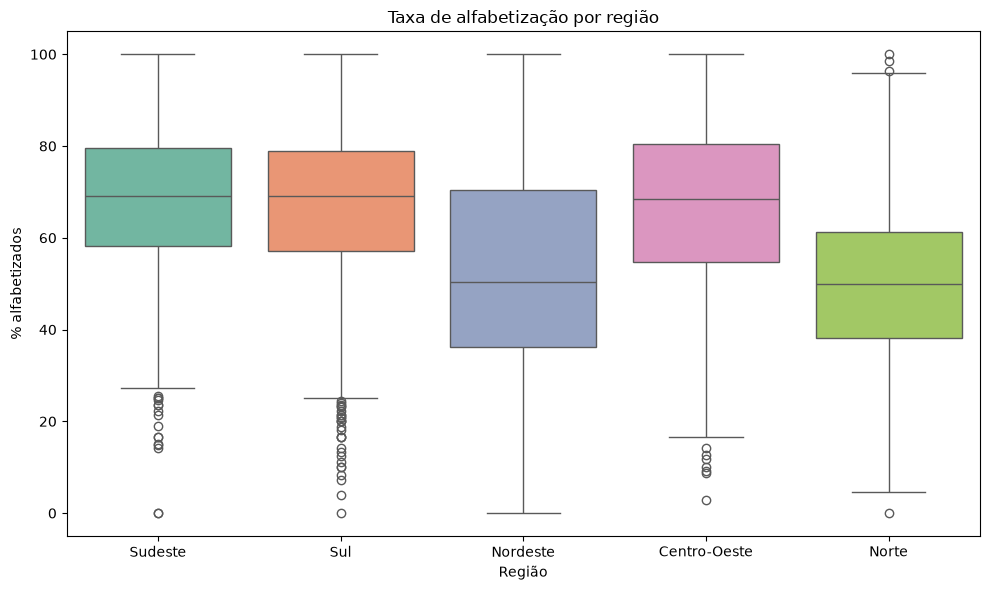

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(data=wide, x='nome_regiao', y='pc_indicador_alfabetizacao', hue='nome_regiao', palette='Set2', legend=False)
plt.title('Taxa de alfabetização por região')
plt.xlabel('Região')
plt.ylabel('% alfabetizados')
plt.tight_layout()
plt.show()

In [14]:
wide.groupby('ds_rede')['pc_indicador_alfabetizacao'].agg(['mean', 'median', 'std']).round(2).sort_values('mean', ascending=False)

,mean,median,std
ds_rede,,,
Privada,66.67,66.67,NaN
Estadual,63.56,64.54,19.82
Municipal,61.79,62.76,19.82


### Por que `nome_regiao`, `sigla_uf` e `ds_rede` foram selecionadas?
Essas variáveis foram escolhidas porque capturam diferenças estruturais que impactam diretamente o desempenho escolar:
- região: contexto econômico, histórico educacional e infraestrutura regional
- UF: variações institucionais e políticas públicas
- rede: diferencia gestão, financiamento e organização escolar

Essas variáveis não explicam a alfabetização sozinhas, mas ajudam a controlar heterogeneidade estrutural no modelo.

In [15]:
wide[['pc_indicador_alfabetizacao', 'vl_proficiencia_media', 'qt_alunos_avaliados']].corr().round(3)

,pc_indicador_alfabetizacao,vl_proficiencia_media,qt_alunos_avaliados
pc_indicador_alfabetizacao,1.000,0.925,-0.036
vl_proficiencia_media,0.925,1.000,-0.037
qt_alunos_avaliados,-0.036,-0.037,1.000


### Por que `vl_proficiencia_media` e `qt_alunos_avaliados` foram selecionadas?
- `vl_proficiencia_media`: mede o rendimento geral em leitura/escrita e tem relação direta com o conceito de alfabetização
- `qt_alunos_avaliados`: expressa o volume de informação disponível e também ajuda a reduzir ruído estatístico em observações pequenas

A correlação positiva entre proficiência e alfabetização reforça que o indicador de alfabetização não é apenas um dado isolado; ele acompanha o desempenho geral em leitura.

## 3. Exploração da base socioeconômica: Cadastro Único (`dados_cadunico_2023_a_2026.csv`)

Esta base não é o alvo em si, mas é muito relevante porque contém fatores externos ao ambiente escolar que tendem a afetar a alfabetização. O foco principal é a renda e a vulnerabilidade socioeconômica.

### Variáveis selecionadas e por que elas importam
- `qtd_fam_pobreza`
- `qtd_fam_baixa_renda`
- `qtd_fam_ate_meio_sm`
- `qtd_fam_renda_zero`
- `taxa_atualizacao_geral_pct`
- `taxa_atualizacao_ate_meio_sm_pct`

Elas capturam a magnitude da pobreza e a situação de vulnerabilidade familiar, que são fatores clássicos associados a menor desempenho escolar.

                            pc_indicador_alfabetizacao  vl_proficiencia_media  \
pc_indicador_alfabetizacao                       1.000                  0.925   
vl_proficiencia_media                            0.925                  1.000   
qtd_fam_pobreza                                 -0.060                 -0.050   
qtd_fam_baixa_renda                             -0.034                 -0.031   
qtd_fam_ate_meio_sm                             -0.055                 -0.047   
qtd_fam_renda_zero                              -0.041                 -0.035   
taxa_atualizacao_geral_pct                      -0.141                 -0.083   

                            qtd_fam_pobreza  qtd_fam_baixa_renda  \
pc_indicador_alfabetizacao           -0.060               -0.034   
vl_proficiencia_media                -0.050               -0.031   
qtd_fam_pobreza                       1.000                0.931   
qtd_fam_baixa_renda                   0.931                1.000   
qtd_fam_ate

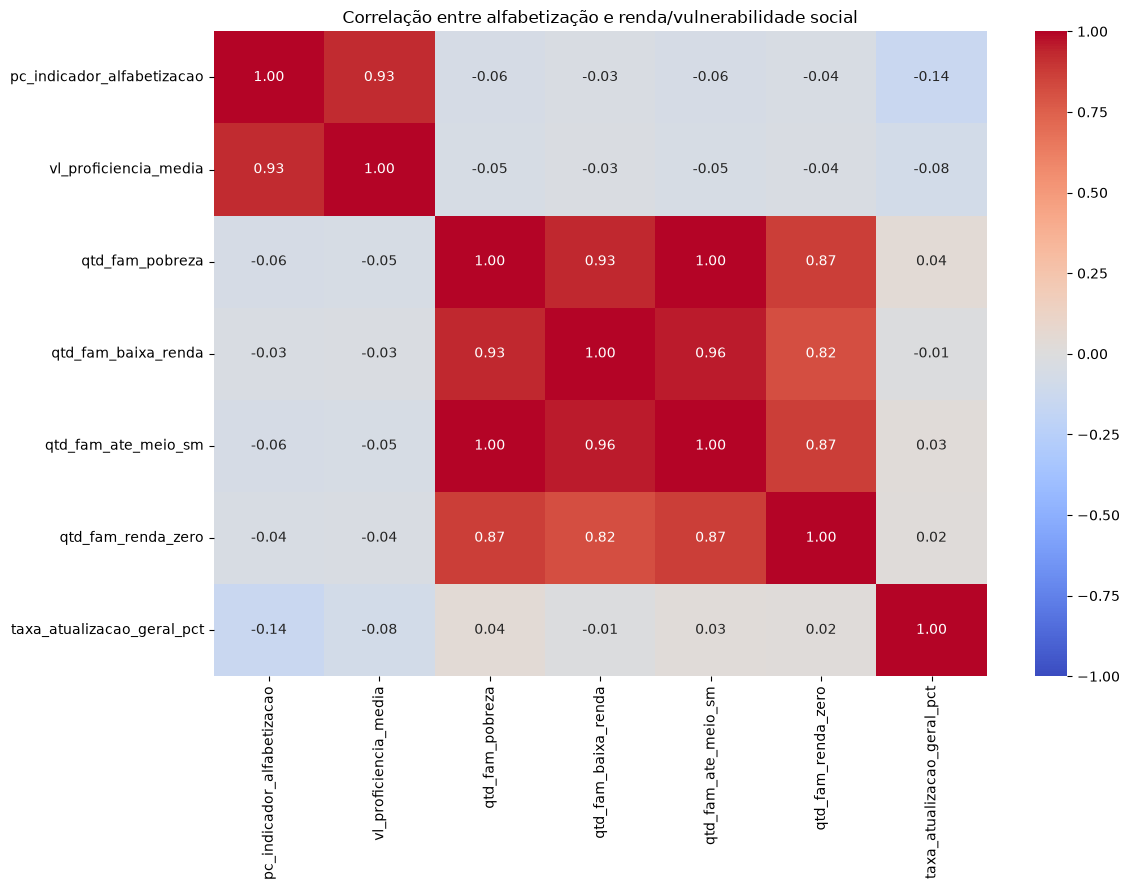

In [17]:
cad = pd.read_csv(base_path / 'dados_cadunico_2023_a_2026.csv')
cad['ano'] = cad['ano_mes'].astype(str).str[:4].astype(int)
cad = cad.rename(columns={'codigo_ibge': 'id_municipio'})

cad_agg = cad.groupby(['id_municipio', 'ano'], as_index=False).agg(
    qtd_fam_pobreza=('qtd_fam_pobreza', 'sum'),
    qtd_fam_baixa_renda=('qtd_fam_baixa_renda', 'sum'),
    qtd_fam_ate_meio_sm=('qtd_fam_ate_meio_sm', 'sum'),
    qtd_fam_renda_zero=('qtd_fam_renda_zero', 'sum'),
    taxa_atualizacao_geral_pct=('taxa_atualizacao_geral_pct', 'mean'),
    taxa_atualizacao_ate_meio_sm_pct=('taxa_atualizacao_ate_meio_sm_pct', 'mean')
)

wide['id_municipio_6'] = wide['id_municipio'] // 10

base = wide.merge(cad_agg, left_on=['id_municipio_6', 'nu_ano'], right_on=['id_municipio', 'ano'], how='left').drop(columns=['ano'], errors='ignore')

corr = base[['pc_indicador_alfabetizacao', 'vl_proficiencia_media', 'qtd_fam_pobreza', 'qtd_fam_baixa_renda', 'qtd_fam_ate_meio_sm', 'qtd_fam_renda_zero', 'taxa_atualizacao_geral_pct']].corr().round(3)
print(corr)

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f', vmin=-1, vmax=1, center=0)
plt.title('Correlação entre alfabetização e renda/vulnerabilidade social')
plt.tight_layout()
plt.show()

In [18]:
print(wide['id_municipio'].head())
print(cad_agg['id_municipio'].head())

wide[(wide['id_municipio'] // 10) == 311550]


0    3101805
1    3102605
2    3104106
3    3107406
4    3109402
Name: id_municipio, dtype: int64
0    110001
1    110001
2    110001
3    110001
4    110002
Name: id_municipio, dtype: int64


,id_municipio,nu_rede,nu_serie,id_indicador_municipio,nome_uf,nome_regiao,ds_rede,qt_alunos_avaliados,qt_alunos_alfabetizados,qt_alunos_alfabetizados_corte,...,pc_meta_2026,pc_meta_2027,pc_meta_2028,pc_meta_2029,pc_meta_2030,pc_meta_ano_corrente,vl_gap_meta_resultado,nu_ano,sigla_uf,id_municipio_6
160,3115508,2,2,5170505779524026576,Minas Gerais,Sudeste,Estadual,29,20,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,MG,311550
518,3115508,2,2,-2451063658158153780,Minas Gerais,Sudeste,Estadual,24,13,13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024,MG,311550
1656,3115508,3,2,611324148562677700,Minas Gerais,Sudeste,Municipal,144,110,110,...,77.99,78.51,79.01,79.51,80.0,NaN,NaN,2023,MG,311550
1714,3115508,3,2,5223231788068403683,Minas Gerais,Sudeste,Municipal,136,106,106,...,77.99,78.51,79.01,79.51,80.0,76.93,1.27,2024,MG,311550


### Interpretação
A correlação negativa entre alfabetização e pobreza é um sinal forte: municípios com mais famílias em extrema vulnerabilidade tendem a apresentar piores taxas de alfabetização. Isso é justamente o tipo de associação que um modelo supervisionado precisa capturar, porque o nível socioeconômico pode explicar parte do desempenho mesmo quando a infraestrutura escolar é semelhante.

Por essa razão, o Cadastro Único entra no conjunto de preditoras, mas em formato agregado por município/ano.

## 4. Exploração da base de infraestrutura escolar: Censo Escolar (`censo_escolar_2023_2024.csv`)

O Censo Escolar traz informações muito importantes sobre a infraestrutura das escolas, como:
- `agua_potavel`
- `energia_rede_publica`
- `esgoto_rede_publica`
- `biblioteca`
- `sala_leitura`
- `laboratorio_informatica`
- `internet`
- `tipo_localizacao`
- `rede`

### Por que essa base foi explorada, mas não entra diretamente como base principal?
Porque o Censo é escolar e a unidade de análise do alvo é município/ano. Isso exige agregação por município, o que faz com que o conjunto de variáveis se torne mais complexo e potencialmente menos direto do que o município já oferece em indicadores de proficiência e pobreza.

Em outras palavras: a base é relevante, mas não é a base mais eficiente para a previsão imediata, a menos que seja agregada e integrada corretamente. Ainda assim, ela é importante como variáveis de contexto e de infraestrutura escolar.

In [20]:
censo = pd.read_csv(base_path / 'censo_escolar_2023_2024.csv')
print(censo.columns.tolist())
print('\nResumo de infraestrutura escolar:')
infra_cols = ['agua_potavel', 'energia_rede_publica', 'esgoto_rede_publica', 'biblioteca', 'sala_leitura', 'laboratorio_informatica', 'internet']
print(censo[infra_cols].isna().sum())
print(censo[infra_cols].mean().round(3))

# proporção por tipo de localizacao
print('\nTipo de localizacao:')
print(censo['tipo_localizacao'].value_counts(dropna=False).head())

['ano', 'sigla_uf', 'id_municipio', 'id_escola', 'rede', 'tipo_localizacao', 'tipo_situacao_funcionamento', 'agua_potavel', 'energia_rede_publica', 'esgoto_rede_publica', 'biblioteca', 'sala_leitura', 'laboratorio_informatica', 'internet', 'internet_alunos', 'desktop_aluno', 'computador_portatil_aluno', 'tablet_aluno', 'quantidade_sala_utilizada', 'sala_atendimento_especial']

Resumo de infraestrutura escolar:
agua_potavel               71875
energia_rede_publica       71875
esgoto_rede_publica        71875
biblioteca                 71875
sala_leitura               71875
laboratorio_informatica    71875
internet                   71875
dtype: int64
agua_potavel               0.960
energia_rede_publica       0.969
esgoto_rede_publica        0.577
biblioteca                 0.367
sala_leitura               0.277
laboratorio_informatica    0.299
internet                   0.915
dtype: float64

Tipo de localizacao:
tipo_localizacao
1    288618
2    144552
Name: count, dtype: int64


## 5. Exploração das bases derivadas: metas, comparação e evolução temporal

As bases `resultado_metas_municipio.csv`, `comparacao_metas_resultados.csv` e `evolucao_temporal_indicador.csv` são importantes para entender a dinâmica do indicador, mas não devem entrar como preditoras diretas no modelo supervisionado por um motivo importante: elas são derivadas do próprio alvo ou muito próximas dele.

### `resultado_metas_municipio.csv`
- expressão do resultado do município para a meta de alfabetização
- útil para avaliar desempenho no nível estratégico
- não é uma variável explicativa independente, e sim uma transformação do indicador alvo

### `comparacao_metas_resultados.csv`
- compara meta e resultado para cada município
- útil para avaliação institucional e acompanhamento da política pública
- não deve entrar como feature se o objetivo é prever o próprio resultado atual

### `evolucao_temporal_indicador.csv`
- mostra a evolução do indicador ao longo dos anos
- útil para análise temporal e visualização de tendência
- risco de vazamento: o valor atual pode ficar muito correlacionado com o próprio passado recente do alvo

Essas bases ajudam a interpretar a evolução do indicador, mas são insuficientes como fonte principal de predição por causa do problema de dependência do próprio alvo.

In [21]:
# Visão rápida das bases derivadas
for name, df in [('res_meta', res_meta), ('comp_meta', comp_meta), ('evol', evol)]:
    print(f'\n=== {name} ===')
    print(df.columns.tolist()[:10])
    print(df.head(2).to_string(index=False))


=== res_meta ===
['id_resultado_municipio', 'id_municipio', 'nome_uf', 'nome_regiao', 'nu_serie', 'nu_rede', 'ds_rede', 'pc_taxa_alfabetizacao', 'vl_media_portugues', 'pc_aluno_nivel_0']
 id_resultado_municipio  id_municipio      nome_uf nome_regiao  nu_serie  nu_rede  ds_rede  pc_taxa_alfabetizacao  vl_media_portugues  pc_aluno_nivel_0  pc_aluno_nivel_1  pc_aluno_nivel_2  pc_aluno_nivel_3  pc_aluno_nivel_4  pc_aluno_nivel_5  pc_aluno_nivel_6  pc_aluno_nivel_7  pc_aluno_nivel_8  pc_participacao_meta  pc_meta_2024  pc_meta_2025  pc_meta_2026  pc_meta_2027  pc_meta_2028  pc_meta_2029  pc_meta_2030         ts_insercao  nu_ano sigla_uf
    6017244195368679562       3118502 Minas Gerais     Sudeste         2        5  Pública                  38.89              726.16               0.0              0.00             27.78             16.67             33.33             16.67              5.56               0.0               0.0                   NaN           NaN           NaN           NaN

## 6. Exploração das bases agregadas por UF e Brasil

As bases `indicadores_educacionais_uf_2021_2026.csv` e `indicadores_educacionais_brasil_2021_2026.csv` são muito úteis para contextualizar tendências macro, mas não servem como base principal para a previsão do alvo porque são agregadas em nível geográfico superior.

### Limitações
- perdem a granularidade municipal
- não possuem observações compatíveis com a unidade alvo desejada
- tendem a mascarar heterogeneidades dentro da UF ou do Brasil
- em muitos casos, estão mais próximas de um diagnóstico macro do que de predição local

### Uso correto destas bases
Essas bases devem ser usadas para:
- comparar tendências nacionais e regionais
- validar se os padrões observados em município se alinham com o panorama macro
- gerar hipóteses de contexto, mas não para aprender diretamente o comportamento do município

In [22]:
uf[['ano', 'sigla_uf', 'localizacao', 'rede', 'alunos_por_turma_ef', 'distorcao_idade_serie_pct_ef', 'taxa_aprovacao_pct_ef']].head(3)

,ano,sigla_uf,localizacao,rede,alunos_por_turma_ef,distorcao_idade_serie_pct_ef,taxa_aprovacao_pct_ef
0,2021,ES,Urbana,Federal,6.5,NaN,99.7
1,2021,PB,Urbana,Federal,8.0,NaN,100.0
2,2021,PB,Total,Federal,8.1,NaN,100.0


In [23]:
print('Brasil sample:')
print(brasil[['ano', 'localizacao', 'rede', 'alunos_por_turma_ef', 'distorcao_idade_serie_pct_ef', 'taxa_aprovacao_pct_ef']].head(3).to_string(index=False))

Brasil sample:
 ano localizacao    rede  alunos_por_turma_ef  distorcao_idade_serie_pct_ef  taxa_aprovacao_pct_ef
2021      Urbana Privada                 18.5                           4.4                   98.9
2021       Total Privada                 18.5                           4.4                   98.9
2021       Rural Privada                 17.0                           9.0                   97.3


## 7. Variáveis finais selecionadas para o modelo supervisionado

Com base na EDA, as variáveis que melhor equilibram explicabilidade, qualidade preditiva e viabilidade prática para a previsão futura do aluno são:

### Variáveis educacionais - BASE WIDE_ANALITICA_ALFABETIZACAO
- `pc_indicador_alfabetizacao` → melhor proxy de label disponível; representa a taxa de alfabetização do município/ano e pode ser convertida em label binário
- `vl_proficiencia_media`
- `vl_proficiencia_mediana`
- `qt_alunos_avaliados`
- `nu_serie`
- `ds_rede`

### Variáveis territoriais - BASE CENSO_ESCOLAR_2023_2024
- `nome_regiao`
- `sigla_uf`
- `tipo_localizacao` (quando agregada ou disponível a partir do Censo)

### Variáveis socioeconômicas - BASE DADOS_CADUNICO_2023_A_2026
- `qtd_fam_pobreza`
- `qtd_fam_baixa_renda`
- `qtd_fam_ate_meio_sm`
- `qtd_fam_renda_zero`
- `taxa_atualizacao_geral_pct`
- `taxa_atualizacao_ate_meio_sm_pct`

OBS: id_municipio (7 dígitos) se relaciona com codigo_ibge do CadÚnico via id_municipio // 10.

### Por que estas foram eleitas?
Porque elas combinam:
- forte associação com a alfabetização observada;
- presença em um nível de agregação razoável para aproximar o problema do aluno;
- menor risco de redundância direta com o próprio alvo;
- consistência com a estrutura real dos dados disponíveis.

Essa estratégia não elimina a limitação do nível de observação, mas é a melhor forma de aproveitar os dados disponíveis para produzir um modelo útil e economicamente viável.

### Importante: o alvo por aluno não existe em base

Como não há base com a classificação individual do aluno, o alvo ideal deve ser aproximado por um proxy. A solução mais defensável é:
- **interpretar a predição como risco de alfabetização do aluno em função do ambiente em que ele está inserido.**

- transformar `pc_indicador_alfabetizacao` em um rótulo binário em nível de município/ano, por exemplo `alfabetizado = 1` se `pc_indicador_alfabetizacao >= 50%`;- usar esse proxy como label para treinar o modelo contextual;

## 8. Hipóteses analíticas finais

- Municípios com menor pobreza e maior renda familiar tendem a apresentar maior alfabetização, o que sugere menor risco de não alfabetização para os alunos daquele contexto.
- Regiões e redes com melhor infraestrutura e melhor organização escolar podem apresentar maior taxa de alfabetização e, portanto, melhor desempenho do aluno.
- Infraestrutura escolar é relevante, mas em nível individual ela não é observável diretamente; por isso, ela deve funcionar como contexto agregado e não como substituto do alvo verdadeiro.

## 9. Conclusão final

A EDA mostra que os dados disponíveis não permitem prever literalmente o aluno individualmente, mas permitem construir uma previsão contextual e robusta do risco de alfabetização a partir de informações agregadas do município, rede e perfil socioeconômico.

Em termos práticos:
- a base de indicadores municipais é a mais importante para o problema;
- o Cadastro Único fornece o contexto socioeconômico mais relevante;
- o Censo Escolar adiciona contexto de infraestrutura e estrutura escolar;
- as bases de meta, evolução e comparação são úteis para diagnóstico institucional, mas não devem ser a base principal do modelo preditivo;
- as bases UF e Brasil servem para contextualização macro, mas não têm granularidade suficiente para o alvo de aluno.

Logo, a melhor estratégia para a previsão futura é treinar um modelo com o proxy de alfabetização em nível municipal/ano usando educação + território + renda, e interpretar a saída como probabilidade de alfabetização do aluno dado o contexto em que ele está inserido. Isso é a melhor aproximação possível com os dados fornecidos.